# Import

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

# Konfigurasi


In [2]:
spark = SparkSession.builder \
    .appName("FraudClassification") \
    .master("local[2]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark

# Proses

## Load Data

In [3]:
df = spark.read.parquet(
    "hdfs://namenode:9000/data/processed/fintech/fraudTrain_clean"
)
df.printSchema()

root
 |-- cc_num: long (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: double (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- unix_time: integer (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- is_fraud: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- age: long (nullable = true)
 |-- distance: double (nullabl

## Sampling Data

In [4]:
df_sample  = df.sample(
    fraction=0.5,
    seed=42
)

print("Jumlah data sample:", df.count())


Jumlah data sample: 1296675


## Feature Selection

In [5]:
feature_columns = [
    "amt",
    "age",
    "hour",
    "day_of_week",
    "is_weekend"
]

target_column = "is_fraud"
df_selected  = (
    df_sample.select(feature_columns + [target_column])
)
df_selected.show(2)

+------+---+----+-----------+----------+--------+
|   amt|age|hour|day_of_week|is_weekend|is_fraud|
+------+---+----+-----------+----------+--------+
|242.56| 43|   0|          1|         1|       0|
| 53.63| 32|   0|          1|         1|       0|
+------+---+----+-----------+----------+--------+
only showing top 2 rows



## Vector Assembler

In [6]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
)

df_featured  = assembler.transform(df_selected)

df_featured.select(
    "features",
    "is_fraud"
).show(5, truncate=False)

+-------------------------+--------+
|features                 |is_fraud|
+-------------------------+--------+
|[242.56,43.0,0.0,1.0,1.0]|0       |
|[53.63,32.0,0.0,1.0,1.0] |0       |
|[72.66,24.0,0.0,1.0,1.0] |0       |
|[79.45,49.0,0.0,1.0,1.0] |0       |
|[122.85,29.0,0.0,1.0,1.0]|0       |
+-------------------------+--------+
only showing top 5 rows



In [7]:
df_final = df_featured.select(
    "features",
    "is_fraud"
)
df_final.show(3)

+--------------------+--------+
|            features|is_fraud|
+--------------------+--------+
|[242.56,43.0,0.0,...|       0|
|[53.63,32.0,0.0,1...|       0|
|[72.66,24.0,0.0,1...|       0|
+--------------------+--------+
only showing top 3 rows



## Train Test Split

In [8]:
train_df, test_df = df_final.randomSplit(
    [0.8, 0.2],
    seed=42
)

In [9]:
train_df.groupBy("is_fraud").count().show()


+--------+------+
|is_fraud| count|
+--------+------+
|       1|  2942|
|       0|516261|
+--------+------+



In [10]:
test_df.groupBy("is_fraud").count().show()


+--------+------+
|is_fraud| count|
+--------+------+
|       1|   783|
|       0|129197|
+--------+------+



## Down Sampling - Handling Imbalance

In [11]:
sampling_list = [
    0.1,
    0.25,
    0.5,
    0.75
]

results = []

# EVALUATORS
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="is_fraud",
    predictionCol="prediction",
    metricName="f1"
)

pr_eval = BinaryClassificationEvaluator(
    labelCol="is_fraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

roc_eval = BinaryClassificationEvaluator(
    labelCol="is_fraud",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)


Normal Class Sampling: 0.1
Class Distribution:
+--------+-----+
|is_fraud|count|
+--------+-----+
|       1| 2942|
|       0|51596|
+--------+-----+

Accuracy  : 0.993
Precision : 0.995
Recall    : 0.993
F1 Score  : 0.994
PR AUC    : 0.534
ROC AUC   : 0.950


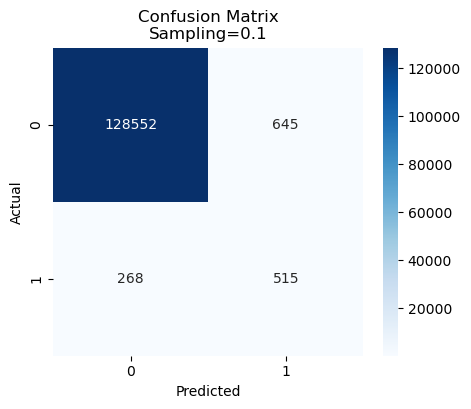


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.998     0.995     0.996    129197
           1      0.444     0.658     0.530       783

    accuracy                          0.993    129980
   macro avg      0.721     0.826     0.763    129980
weighted avg      0.995     0.993     0.994    129980

Normal Class Sampling: 0.25
Class Distribution:
+--------+------+
|is_fraud| count|
+--------+------+
|       1|  2942|
|       0|129595|
+--------+------+

Accuracy  : 0.994
Precision : 0.995
Recall    : 0.994
F1 Score  : 0.995
PR AUC    : 0.562
ROC AUC   : 0.950


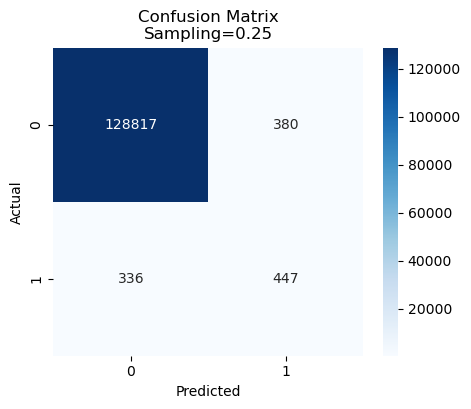


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.997     0.997     0.997    129197
           1      0.541     0.571     0.555       783

    accuracy                          0.994    129980
   macro avg      0.769     0.784     0.776    129980
weighted avg      0.995     0.994     0.995    129980

Normal Class Sampling: 0.5
Class Distribution:
+--------+------+
|is_fraud| count|
+--------+------+
|       1|  2942|
|       0|258567|
+--------+------+

Accuracy  : 0.996
Precision : 0.995
Recall    : 0.996
F1 Score  : 0.995
PR AUC    : 0.571
ROC AUC   : 0.948


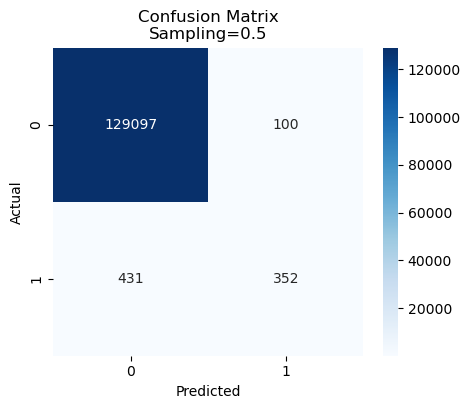


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.997     0.999     0.998    129197
           1      0.779     0.450     0.570       783

    accuracy                          0.996    129980
   macro avg      0.888     0.724     0.784    129980
weighted avg      0.995     0.996     0.995    129980

Normal Class Sampling: 0.75
Class Distribution:
+--------+------+
|is_fraud| count|
+--------+------+
|       1|  2942|
|       0|387060|
+--------+------+

Accuracy  : 0.995
Precision : 0.995
Recall    : 0.995
F1 Score  : 0.995
PR AUC    : 0.500
ROC AUC   : 0.918


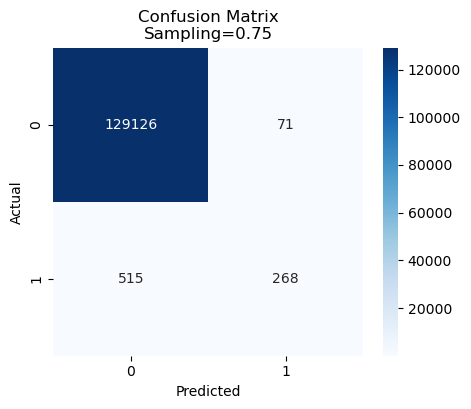


=== Classification Report ===
              precision    recall  f1-score   support

           0      0.996     0.999     0.998    129197
           1      0.791     0.342     0.478       783

    accuracy                          0.995    129980
   macro avg      0.893     0.671     0.738    129980
weighted avg      0.995     0.995     0.995    129980



In [12]:
for sample_ratio in sampling_list:

    print("=" * 70)
    print(f"Normal Class Sampling: {sample_ratio}")

    # DOWNSAMPLING
    train_sample = train_df.sampleBy(
        "is_fraud",
        fractions={
            0: sample_ratio,
            1: 1.0
        },
        seed=42
    )

    print("Class Distribution:")
    train_sample.groupBy(
        "is_fraud"
    ).count().show()

    # MODEL
    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="is_fraud",
        numTrees=5,
        maxDepth=5,
        seed=42
    )

    rf_model = rf.fit(train_sample)

    # PREDICTION
    pred_rf = rf_model.transform(
        test_df
    )

    # METRICS
    accuracy = accuracy_eval.evaluate(pred_rf)
    precision = precision_eval.evaluate(pred_rf)
    recall = recall_eval.evaluate(pred_rf)
    f1_score = f1_eval.evaluate(pred_rf)

    pr_auc = pr_eval.evaluate(pred_rf)
    roc_auc = roc_eval.evaluate(pred_rf)

    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1 Score  : {f1_score:.3f}")
    print(f"PR AUC    : {pr_auc:.3f}")
    print(f"ROC AUC   : {roc_auc:.3f}")

    # SAVE RESULT
    results.append({
        "sample_ratio": sample_ratio,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    })

    pred_pd = pred_rf.select(
        "is_fraud",
        "prediction"
    ).toPandas()

    # CONFUSION MATRIX
    cm = confusion_matrix(
        pred_pd["is_fraud"],
        pred_pd["prediction"]
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix\nSampling={sample_ratio}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # CLASSIFICATION REPORT
    print("\n=== Classification Report ===")

    print(
        classification_report(
            pred_pd["is_fraud"],
            pred_pd["prediction"],
            digits=3
        )
    )

# Output

In [13]:
# RESULT TABLE
result_df = pd.DataFrame(results)
result_df

,sample_ratio,accuracy,precision,recall,f1_score,pr_auc,roc_auc
0,0.10,0.992976,0.994583,0.992976,0.993652,0.533835,0.949938
1,0.25,0.994491,0.994646,0.994491,0.994566,0.561689,0.949901
2,0.50,0.995915,0.995360,0.995915,0.995370,0.570827,0.947781
3,0.75,0.995492,0.994790,0.995492,0.994603,0.499939,0.917980


In [14]:
# # SAVE PREDICTION RESULT
pred_rf.select("prediction","probability","is_fraud").write .mode("overwrite") .parquet("hdfs://namenode:9000/data/analytics/fintech/fraud_prediction_under")